<a href="https://colab.research.google.com/github/christy5165/Denoising_Autoencoder.ipynb/blob/main/GAN-WK.9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Training at 4x4 Resolution ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


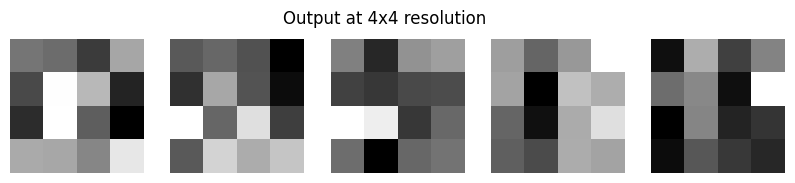


--- Training at 8x8 Resolution ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


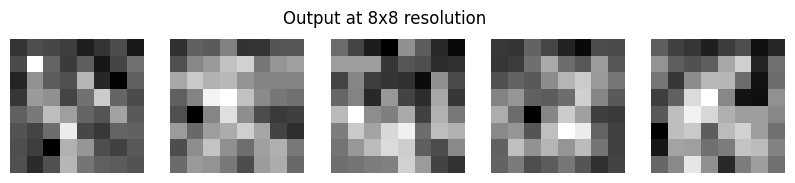


--- Training at 16x16 Resolution ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


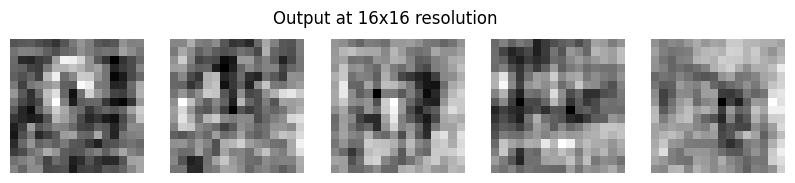

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuration - We will grow from 4x4 to 16x16
LATENT_DIM = 100

def build_generator(resolution):
    """Creates a generator that grows based on the resolution."""
    model = tf.keras.Sequential(name=f"Generator_{resolution}x{resolution}")

    # Start with a tiny 4x4 base
    model.add(layers.Dense(4 * 4 * 128, input_dim=LATENT_DIM))
    model.add(layers.Reshape((4, 4, 128)))
    model.add(layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"))

    # Grow the resolution if requested
    if resolution >= 8:
        model.add(layers.UpSampling2D()) # Grow to 8x8
        model.add(layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"))

    if resolution >= 16:
        model.add(layers.UpSampling2D()) # Grow to 16x16
        model.add(layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"))

    # Final Image Layer (1 channel for grayscale)
    model.add(layers.Conv2D(1, kernel_size=3, padding="same", activation="tanh"))
    return model

def train_progressive_gan(res_list):
    """Trains the GAN at each resolution step."""
    for res in res_list:
        print(f"\n--- Training at {res}x{res} Resolution ---")

        # Build the model for this stage
        generator = build_generator(res)

        # Generate some "fake" images to show progress
        noise = np.random.normal(0, 1, (5, LATENT_DIM))
        generated_images = generator.predict(noise)

        # Plot the progress
        plt.figure(figsize=(10, 2))
        for i in range(5):
            plt.subplot(1, 5, i+1)
            plt.imshow(generated_images[i].reshape(res, res), cmap='gray')
            plt.axis('off')
        plt.suptitle(f"Output at {res}x{res} resolution")
        plt.show()

# Run the progression
resolutions = [4, 8, 16]
train_progressive_gan(resolutions)